# Plot community compositions

Plot community compositions calculated from elementary community modes and from Pycomo for comparison.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_compositions(pattern, mus, plotted_mus, mins=None, maxs=None, organism="Geobacter"):
    """calculate community compositions from the elementary modes.
    If there are too many modes, they are sampled, 
    making sure that the extreme points are always plotted.
    """
    color = "#00a797"
    compute_extrema = mins is None or maxs is None
    max_points = 500_000
    rng = np.random.default_rng(4)
    if compute_extrema:
        mins, maxs, plotted_mus = [], [], []
    for i, mu in enumerate(mus):
        try:
            composition = pd.read_csv(
                f"results/ecms2comp_{pattern}_{round(mu,2)}.csv",
                index_col=0
            )
        except FileNotFoundError:
            print(f"Results for {pattern} mu={mu} not available")
            continue
        values = composition[organism].to_numpy()
        if compute_extrema:
            plotted_mus.append(mu)
            mins.append(values.min())
            maxs.append(values.max())
        print(pattern, round(mu, 2), len(values))
        # Randomly sample points for plotting only, while always keeping the extremes
        if len(values) > max_points:
            min_idx = np.argmin(values)
            max_idx = np.argmax(values)

            mask = np.ones(len(values), dtype=bool)
            mask[min_idx] = False
            mask[max_idx] = False
            remaining_idx = np.flatnonzero(mask)

            n_sample = max_points - 2
            sampled_idx = rng.choice(remaining_idx, size=n_sample, replace=False)

            plot_idx = np.concatenate([sampled_idx, [min_idx, max_idx]])
            values_plot = values[plot_idx]
        else:
            values_plot = values
        plt.scatter(
            values_plot,
            [mu] * len(values_plot),
            color="black",
            alpha=0.6,
            zorder=2,
            s=7,
            label="EFMs" if i == 0 else None
        )
        
    plotted_mus = np.array(plotted_mus)
    mins = np.array(mins)
    maxs = np.array(maxs)
    
    mask = mins - maxs < -1e-6
    
    plt.fill_betweenx(
        plotted_mus[mask],
        mins[mask],
        maxs[mask],
        alpha=0.5,
        zorder=1,
        color=color,
        label="pycomo"
    )
    plt.legend(loc="lower right")
    plt.xlabel(f"Fraction of {organism}", size=15)
    plt.ylabel("Growth rate", size=15)
    plt.title(f"Pattern {pattern}")
    plt.savefig(
        f"figures/{pattern}_EFMs.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    return plotted_mus, mins, maxs

In [3]:
pycomo_results = pd.read_csv("results/pycomo_composition_ranges.csv")

In [4]:
with open('tested_growth_rates.pkl', 'rb') as f:
    simulated_mus = pickle.load(f)

mEmC_1 0.66 142
mEmC_1 0.6 29319
mEmC_1 0.54 15948
mEmC_1 0.47 5940
mEmC_1 0.4 7236
mEmC_1 0.33 367456
mEmC_1 0.27 12654636
mEmC_1 0.2 71584369


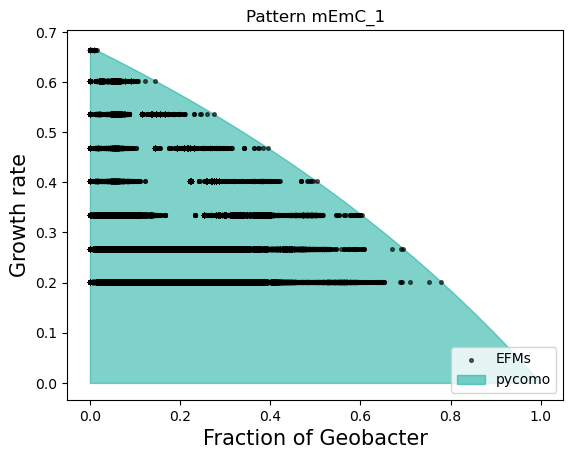

mEmC_3 0.66 40
mEmC_3 0.6 4636
mEmC_3 0.54 5586
mEmC_3 0.47 3492
mEmC_3 0.4 5580
mEmC_3 0.33 348432
mEmC_3 0.27 1171829
mEmC_3 0.2 22630723


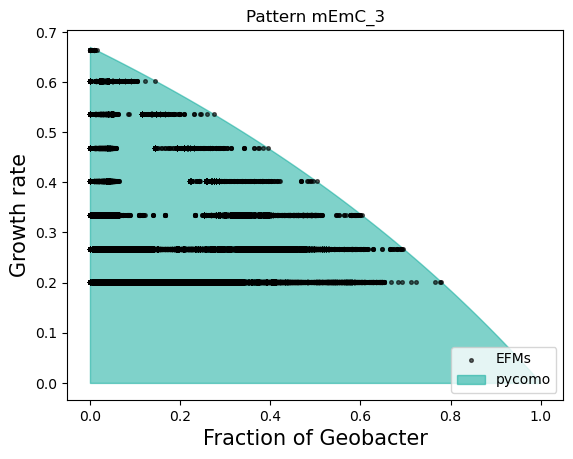

mEmC_2 0.99 22
mEmC_2 0.9 33
mEmC_2 0.8 33
mEmC_2 0.7 183
mEmC_2 0.6 1728
mEmC_2 0.5 12376
mEmC_2 0.4 24340
mEmC_2 0.3 1028577


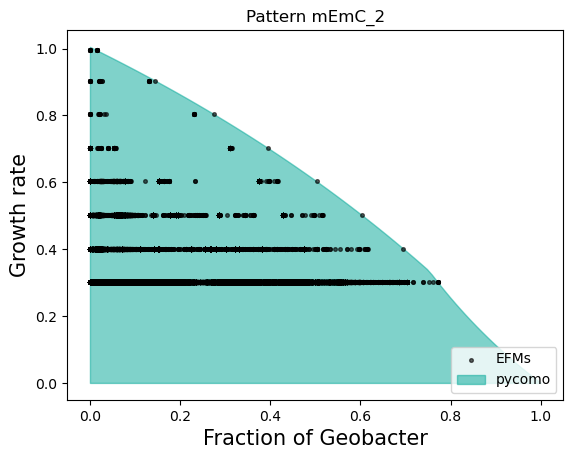

mEmC_4 0.92 3
mEmC_4 0.84 9
mEmC_4 0.74 12
mEmC_4 0.65 518
mEmC_4 0.56 4216
mEmC_4 0.47 8362
mEmC_4 0.37 34498
mEmC_4 0.28 645674


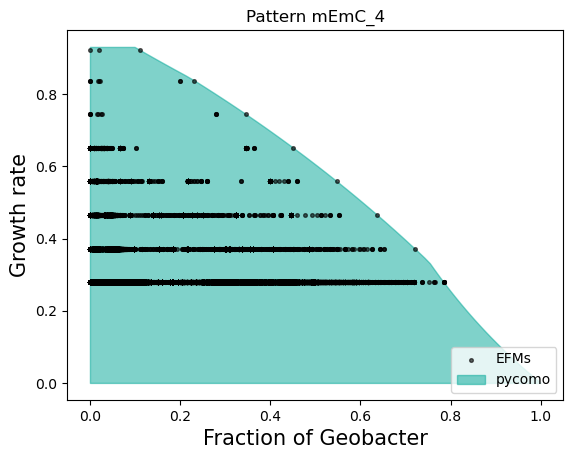

mEmC_5 0.66 2710
mEmC_5 0.6 40520
mEmC_5 0.54 50003
mEmC_5 0.47 52952
mEmC_5 0.4 65368
mEmC_5 0.33 242524
mEmC_5 0.27 770812
mEmC_5 0.2 29788255


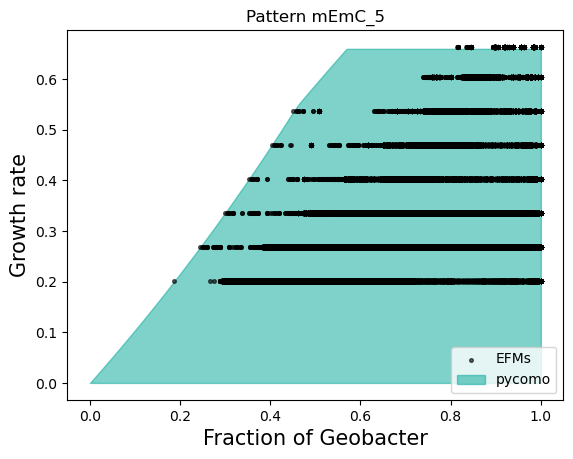

mEmC_6 0.32 5270
mEmC_6 0.29 7602
mEmC_6 0.26 61701
mEmC_6 0.23 286763
mEmC_6 0.2 1016897
mEmC_6 0.16 5941339
mEmC_6 0.13 29884036
mEmC_6 0.1 56619510


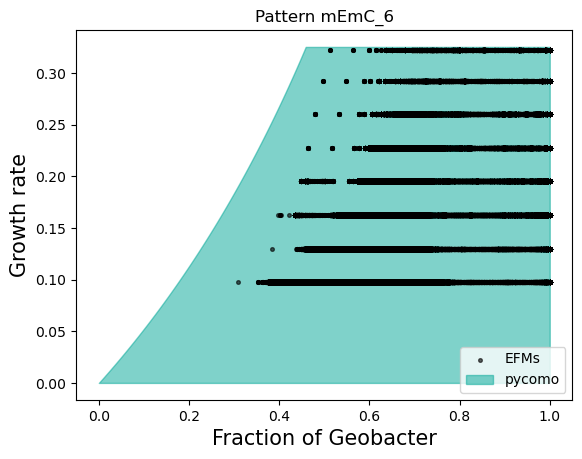

mE_1 0.37 1334
mE_1 0.33 2303
mE_1 0.3 2254
mE_1 0.26 18289
mE_1 0.22 58870
mE_1 0.18 3038257
mE_1 0.15 44599707
Results for mE_1 mu=0.11083393814592404 not available


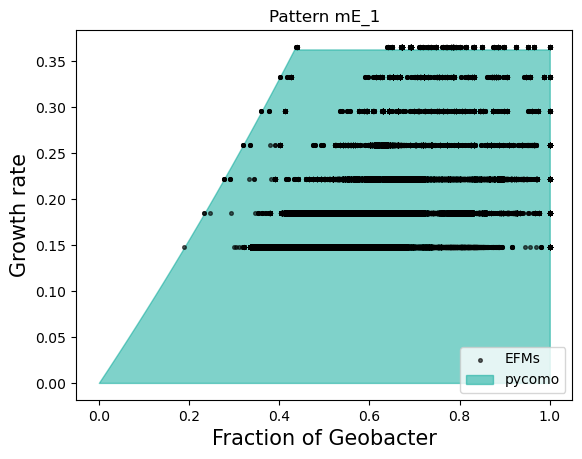

In [5]:
for pattern, mus in simulated_mus.items():
    pycomo_one = pycomo_results[pycomo_results["pattern"] == pattern]
    plotted_mus, mins, maxs = get_compositions(
         pattern, 
         mus, 
         pycomo_one.mu, 
         pycomo_one.min_fraction, 
         pycomo_one.max_fraction)

In [6]:
mins - maxs < -1e-6

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False])

In [7]:
maxs

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [8]:
c_sources = {
    "Geobacter": {"mEmC_1": "M_mal__45__L_e",
                  "mEmC_2": "M_mal__45__L_e",
                  "mEmC_3": "M_mal__45__L_e",
                  "mEmC_4": "M_mal__45__L_e",
                  "mEmC_5": "M_cit_e",
                  "mEmC_6": "M_cit_e",
                  "mE_1": "M_mal__45__L_e"},
    "Rhodoferax": {"mEmC_1": "M_fum_e",
                   "mEmC_3": "M_fum_e",
                   "mEmC_2": "M_cit_e",
                   "mEmC_4": "M_cit_e",
                   "mEmC_5": "M_mal__45__L_e",
                   "mEmC_6": "M_mal__45__L_e",
                   "mE_1": "M_ac_e"}
    }

combos = {"mEmC_1": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_2": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_3": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_4": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_5": ["M_mal__45__L_e", "M_fe2_e"],
          "mEmC_6": ["M_mal__45__L_e", "M_co2_e",  "M_fe2_e"],
          "mE_1": ["M_ac_e"]}

In [9]:
for n, mus in simulated_mus.items():
    print(f"{n} yields")
    for mu in mus:
        
        ecms = pd.read_csv(
            f"results/growing_ecms_Rhodoferax_{n}_{round(mu,2)}.csv")

        rho_p = ecms[combos[n][0]]
        rho_c = ecms[c_sources["Rhodoferax"][n]]

        print(f"{mu:.2f}: {min(abs(rho_p/rho_c)):.2f}-{max(abs(rho_p/rho_c)):.2f}")


mEmC_1 yields
0.66: 0.00-0.01
0.60: 0.00-0.10
0.54: 0.00-0.20
0.47: 0.00-0.30
0.40: 0.00-0.40
0.33: 0.00-0.50
0.27: 0.00-0.60
0.20: 0.00-0.70
mEmC_3 yields
0.66: 0.00-0.01
0.60: 0.00-0.10
0.54: 0.00-0.20
0.47: 0.00-0.30
0.40: 0.00-0.40
0.33: 0.00-0.50
0.27: 0.00-0.60
0.20: 0.00-0.70
mEmC_2 yields
0.99: 0.00-0.02
0.90: 0.00-0.15
0.80: 0.00-0.30
0.70: 0.00-0.45
0.60: 0.00-0.60
0.50: 0.00-0.75
0.40: 0.00-0.90
0.30: 0.00-1.00
mEmC_4 yields
0.92: 0.00-0.12
0.84: 0.00-0.25
0.74: 0.00-0.39
0.65: 0.00-0.53
0.56: 0.00-0.67
0.47: 0.00-0.80
0.37: 0.00-0.94
0.28: 0.00-1.00
mEmC_5 yields
0.66: 1.00-1.00
0.60: 1.00-1.00
0.54: 1.00-1.00
0.47: 1.00-1.00
0.40: 1.00-1.00
0.33: 1.00-1.00
0.27: 1.00-1.00
0.20: 1.00-1.00
mEmC_6 yields
0.32: 1.00-1.00
0.29: 1.00-1.00
0.26: 1.00-1.00
0.23: 1.00-1.00
0.20: 1.00-1.00
0.16: 1.00-1.00
0.13: 1.00-1.00
0.10: 1.00-1.00
mE_1 yields
0.37: 1.00-1.00
0.33: 1.00-1.00
0.30: 1.00-1.00
0.26: 1.00-1.00
0.22: 1.00-1.00
0.18: 1.00-1.00
0.15: 1.00-1.00
0.11: 1.00-1.00


In [10]:
for n, mus in simulated_mus.items():
    print(n)
    for mu in mus:
        
        ecms = pd.read_csv(
            f"results/filtered_ecms_Rhodoferax_{n}_{round(mu,2)}.csv")

        rho_p = ecms[combos[n][0]]
        rho_c = ecms[c_sources["Rhodoferax"][n]]

        print(f"{mu:.2f}: {min(abs(rho_p/rho_c)):.3f}-{max(abs(rho_p/rho_c)):.2f}")



mEmC_1
0.66: 0.010-0.01
0.60: 0.022-0.10
0.54: 0.048-0.20
0.47: 0.167-0.30
0.40: 0.286-0.40
0.33: 0.045-0.50
0.27: 0.017-0.60
0.20: 0.014-0.70
mEmC_3
0.66: 0.010-0.01
0.60: 0.022-0.10
0.54: 0.048-0.20
0.47: 0.167-0.30
0.40: 0.286-0.40
0.33: 0.045-0.50
0.27: 0.017-0.60
0.20: 0.014-0.70
mEmC_2
0.99: 0.015-0.02
0.90: 0.150-0.15
0.80: 0.300-0.30
0.70: 0.450-0.45
0.60: 0.083-0.60
0.50: 0.056-0.75
0.40: 0.038-0.90
0.30: 0.001-1.00
mEmC_4
0.92: 0.124-0.12
0.84: 0.249-0.25
0.74: 0.388-0.39
0.65: 0.009-0.53
0.56: 0.013-0.67
0.47: 0.032-0.80
0.37: 0.007-0.94
0.28: 0.068-1.00
mEmC_5
0.66: 1.000-1.00
0.60: 1.000-1.00
0.54: 1.000-1.00
0.47: 1.000-1.00
0.40: 1.000-1.00
0.33: 1.000-1.00
0.27: 1.000-1.00
0.20: 1.000-1.00
mEmC_6
0.32: 1.000-1.00
0.29: 1.000-1.00
0.26: 1.000-1.00
0.23: 1.000-1.00
0.20: 1.000-1.00
0.16: 1.000-1.00
0.13: 1.000-1.00
0.10: 1.000-1.00
mE_1
0.37: 1.000-1.00
0.33: 1.000-1.00
0.30: 1.000-1.00
0.26: 1.000-1.00
0.22: 1.000-1.00
0.18: 1.000-1.00
0.15: 1.000-1.00
0.11: 1.000-1.00


In [11]:
for n, mus in simulated_mus.items():
    print(f"{n} yields")
    for mu in mus:
        
        ecms = pd.read_csv(
            f"results/growing_ecms_Geobacter_{n}_{round(mu,2)}.csv")

        rho_p = mu
        rho_c = ecms[c_sources["Geobacter"][n]]

        print(f"{mu:.2f}: {min(abs(rho_p/rho_c)):.2f}-{max(abs(rho_p/rho_c)):.2f}")


mEmC_1 yields
0.66: 0.07-0.10
0.60: 0.06-0.10
0.54: 0.05-0.10
0.47: 0.05-0.10
0.40: 0.04-0.10
0.33: 0.03-0.10
0.27: 0.03-0.10
0.20: 0.02-0.10
mEmC_3 yields
0.66: 0.07-0.10
0.60: 0.06-0.10
0.54: 0.05-0.10
0.47: 0.05-0.10
0.40: 0.04-0.10
0.33: 0.03-0.10
0.27: 0.03-0.10
0.20: 0.02-0.10
mEmC_2 yields
0.99: 0.10-0.10
0.90: 0.09-0.10
0.80: 0.08-0.10
0.70: 0.07-0.10
0.60: 0.06-0.10
0.50: 0.05-0.10
0.40: 0.04-0.10
0.30: 0.03-0.10
mEmC_4 yields
0.92: 0.09-0.09
0.84: 0.08-0.10
0.74: 0.07-0.10
0.65: 0.07-0.10
0.56: 0.06-0.10
0.47: 0.05-0.10
0.37: 0.04-0.10
0.28: 0.03-0.10
mEmC_5 yields
0.66: 0.07-0.15
0.60: 0.06-0.15
0.54: 0.05-0.15
0.47: 0.05-0.15
0.40: 0.04-0.15
0.33: 0.03-0.15
0.27: 0.03-0.15
0.20: 0.02-0.15
mEmC_6 yields
0.32: 0.03-0.15
0.29: 0.03-0.15
0.26: 0.03-0.15
0.23: 0.02-0.15
0.20: 0.02-0.15
0.16: 0.02-0.15
0.13: 0.01-0.15
0.10: 0.01-0.15
mE_1 yields
0.37: 0.04-0.10
0.33: 0.03-0.10
0.30: 0.03-0.10
0.26: 0.03-0.10
0.22: 0.02-0.10
0.18: 0.02-0.10
0.15: 0.01-0.10
0.11: 0.01-0.10


In [12]:
for n, mus in simulated_mus.items():
    print(f"{n} yields")
    for mu in mus:
        
        ecms = pd.read_csv(
            f"results/filtered_ecms_Geobacter_{n}_{round(mu,2)}.csv")

        rho_p = ecms[combos[n][0]]
        rho_c = ecms[c_sources["Geobacter"][n]]

        print(f"{mu:.2f}: {min(abs(rho_p/rho_c)):.2f}-{max(abs(rho_p/rho_c)):.2f}")


mEmC_1 yields
0.66: 1.00-1.00
0.60: 1.00-1.00
0.54: 1.00-1.00
0.47: 1.00-1.00
0.40: 1.00-1.00
0.33: 1.00-1.00
0.27: 1.00-1.00
0.20: 1.00-1.00
mEmC_3 yields
0.66: 1.00-1.00
0.60: 1.00-1.00
0.54: 1.00-1.00
0.47: 1.00-1.00
0.40: 1.00-1.00
0.33: 1.00-1.00
0.27: 1.00-1.00
0.20: 1.00-1.00
mEmC_2 yields
0.99: 1.00-1.00
0.90: 1.00-1.00
0.80: 1.00-1.00
0.70: 1.00-1.00
0.60: 1.00-1.00
0.50: 1.00-1.00
0.40: 1.00-1.00
0.30: 1.00-1.00
mEmC_4 yields
0.92: 1.00-1.00
0.84: 1.00-1.00
0.74: 1.00-1.00
0.65: 1.00-1.00
0.56: 1.00-1.00
0.47: 1.00-1.00
0.37: 1.00-1.00
0.28: 1.00-1.00
mEmC_5 yields
0.66: 0.01-0.22
0.60: 0.01-0.32
0.54: 0.01-0.97
0.47: 0.01-1.04
0.40: 0.01-1.10
0.33: 0.00-1.17
0.27: 0.00-1.24
0.20: 0.00-1.30
mEmC_6 yields
0.32: 0.01-0.95
0.29: 0.01-1.01
0.26: 0.01-1.09
0.23: 0.01-1.16
0.20: 0.00-1.23
0.16: 0.00-1.30
0.13: 0.00-1.11
0.10: 0.00-1.16
mE_1 yields
0.37: 0.04-1.28
0.33: 0.01-1.35
0.30: 0.03-1.42
0.26: 0.07-1.49
0.22: 0.03-1.56
0.18: 0.03-1.64
0.15: 0.08-1.71
0.11: 0.08-1.78
